<a href="https://colab.research.google.com/github/ShilpaVutukuru/Python_Tutorials/blob/main/Innomatics_GenAI_Internship_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Advanced GenAI Internship | Entrance Test

In [27]:
import os
import re
import csv
import json
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Loading orders dataset

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
def load_orders(path):
    """Load orders CSV and parse dates."""
    orders = pd.read_csv(path)
    # Parse order_date in format day-month-year
    orders['order_date'] = pd.to_datetime(orders['order_date'], dayfirst=True)
    # Ensure numeric types
    orders['user_id'] = orders['user_id'].astype(int)
    orders['restaurant_id'] = orders['restaurant_id'].astype(int)
    orders['total_amount'] = pd.to_numeric(orders['total_amount'], errors='coerce')
    return orders

path = '/content/drive/MyDrive/orders.csv'

orders_data = load_orders(path)

In [30]:
orders_data.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name
0,1,2508,450,2023-02-18,842.97,New Foods Chinese
1,2,2693,309,2023-01-18,546.68,Ruchi Curry House Multicuisine
2,3,2084,107,2023-07-15,163.93,Spice Kitchen Punjabi
3,4,319,224,2023-10-04,1155.97,Darbar Kitchen Non-Veg
4,5,1064,293,2023-12-25,1321.91,Royal Eatery South Indian


In [31]:
orders_data.shape

(10000, 6)

In [32]:
orders_data.describe()

,order_id,user_id,restaurant_id,order_date,total_amount
count,10000.00000,10000.000000,10000.000000,10000,10000.000000
mean,5000.50000,1504.117700,251.016700,2023-07-02 11:45:53.280000,801.162412
min,1.00000,1.000000,1.000000,2023-01-01 00:00:00,100.200000
25%,2500.75000,761.000000,127.000000,2023-04-01 00:00:00,446.310000
50%,5000.50000,1508.000000,251.000000,2023-07-03 00:00:00,806.295000
75%,7500.25000,2250.250000,376.000000,2023-10-02 00:00:00,1149.227500
max,10000.00000,3000.000000,500.000000,2024-01-01 00:00:00,1499.830000
std,2886.89568,861.727776,144.622558,NaN,405.458753


In [33]:
orders_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         10000 non-null  int64         
 1   user_id          10000 non-null  int64         
 2   restaurant_id    10000 non-null  int64         
 3   order_date       10000 non-null  datetime64[ns]
 4   total_amount     10000 non-null  float64       
 5   restaurant_name  10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 468.9+ KB


## Step 2: Loading users data

In [34]:
def load_users(path2):
    """Load users JSON into DataFrame."""
    users = pd.read_json(path2)
    # Ensure user_id is int
    users['user_id'] = users['user_id'].astype(int)
    return users

path2 = '/content/drive/MyDrive/users.json'

users = load_users(path2)
users.head()

,user_id,name,city,membership
0,1,User_1,Chennai,Regular
1,2,User_2,Pune,Gold
2,3,User_3,Bangalore,Gold
3,4,User_4,Bangalore,Regular
4,5,User_5,Pune,Gold


In [35]:
users.shape

(3000, 4)

In [36]:
users.describe()

,user_id
count,3000.000000
mean,1500.500000
std,866.169729
min,1.000000
25%,750.750000
50%,1500.500000
75%,2250.250000
max,3000.000000


In [37]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     3000 non-null   int64 
 1   name        3000 non-null   object
 2   city        3000 non-null   object
 3   membership  3000 non-null   object
dtypes: int64(1), object(3)
memory usage: 93.9+ KB


## Step 3: Loading restaurants data


In [38]:
def load_restaurants_from_sql(path3):
    """Parse `restaurants.sql` file extracting INSERT rows into a DataFrame.

    This looks for lines like:
      INSERT INTO restaurants VALUES (1, 'Restaurant_1', 'Chinese', 4.8);
    and extracts the four fields.
    """
    with open(path3, 'r', encoding='utf-8') as f:
        sql = f.read()

    # Regex to capture: id, 'name', 'cuisine', rating
    pattern = re.compile(r"INSERT INTO restaurants VALUES\s*\((\d+)\s*,\s*'([^']*)'\s*,\s*'([^']*)'\s*,\s*([0-9.]+)\)\s*;", re.IGNORECASE)
    rows = pattern.findall(sql)

    data = []
    for r in rows:
        rid = int(r[0])
        name = r[1]
        cuisine = r[2]
        rating = float(r[3])
        data.append({'restaurant_id': rid, 'restaurant_name_sql': name, 'cuisine': cuisine, 'rating': rating})

    restaurants = pd.DataFrame(data)
    return restaurants

path3 = '/content/drive/MyDrive/restaurants.sql'

restaurants = load_restaurants_from_sql(path3)

In [39]:
restaurants.head()

,restaurant_id,restaurant_name_sql,cuisine,rating
0,1,Restaurant_1,Chinese,4.8
1,2,Restaurant_2,Indian,4.1
2,3,Restaurant_3,Mexican,4.3
3,4,Restaurant_4,Chinese,4.1
4,5,Restaurant_5,Chinese,4.8


In [40]:
restaurants.shape

(500, 4)

In [41]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   restaurant_id        500 non-null    int64  
 1   restaurant_name_sql  500 non-null    object 
 2   cuisine              500 non-null    object 
 3   rating               500 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 15.8+ KB


## Step 4: Merging 3 datasets


In [42]:
def merge_datasets(orders_data, users, restaurants):
    """Left join orders -> users and restaurants to produce final dataset."""
    # Left join users
    merged = orders_data.merge(users, how='left', on='user_id', suffixes=('', '_user'))
    # Left join restaurants using restaurant_id
    merged = merged.merge(restaurants, how='left', on='restaurant_id', suffixes=('', '_rest'))

    # If orders contained a restaurant_name column, keep it as `restaurant_name_order` for traceability
    if 'restaurant_name' in orders_data.columns:
        merged = merged.rename(columns={'restaurant_name': 'restaurant_name_order'})

    # Standardize column order for readability
    cols = ['order_id', 'order_date', 'user_id', 'name', 'city', 'membership',
            'restaurant_id', 'restaurant_name_order', 'restaurant_name_sql', 'cuisine', 'rating', 'total_amount']
    cols = [c for c in cols if c in merged.columns]
    merged = merged[cols]

    return merged

merged = merge_datasets(orders_data, users, restaurants)

In [43]:
merged.head()

,order_id,order_date,user_id,name,city,membership,restaurant_id,restaurant_name_order,restaurant_name_sql,cuisine,rating,total_amount
0,1,2023-02-18,2508,User_2508,Hyderabad,Regular,450,New Foods Chinese,Restaurant_450,Mexican,3.2,842.97
1,2,2023-01-18,2693,User_2693,Pune,Regular,309,Ruchi Curry House Multicuisine,Restaurant_309,Indian,4.5,546.68
2,3,2023-07-15,2084,User_2084,Chennai,Gold,107,Spice Kitchen Punjabi,Restaurant_107,Mexican,4.0,163.93
3,4,2023-10-04,319,User_319,Bangalore,Gold,224,Darbar Kitchen Non-Veg,Restaurant_224,Chinese,4.8,1155.97
4,5,2023-12-25,1064,User_1064,Pune,Regular,293,Royal Eatery South Indian,Restaurant_293,Italian,3.0,1321.91


In [44]:
merged.shape

(10000, 12)

In [45]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               10000 non-null  int64         
 1   order_date             10000 non-null  datetime64[ns]
 2   user_id                10000 non-null  int64         
 3   name                   10000 non-null  object        
 4   city                   10000 non-null  object        
 5   membership             10000 non-null  object        
 6   restaurant_id          10000 non-null  int64         
 7   restaurant_name_order  10000 non-null  object        
 8   restaurant_name_sql    10000 non-null  object        
 9   cuisine                10000 non-null  object        
 10  rating                 10000 non-null  float64       
 11  total_amount           10000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory 

## Saving the merged dataset to CSV file as 'final_food_delivery_dataset.csv'

In [50]:
def analyze_and_save(merged, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    # Save final merged dataset to Google Drive
    # Adjust the subfolder path as needed, e.g., 'MyProject/food_data/'
    drive_path = '/content/drive/My Drive/' + out_dir
    final_csv = os.path.join(drive_path, 'final_food_delivery_dataset.csv')
    merged.to_csv(final_csv, index=False)

out_dir = '/content/drive/My Drive/Innomatics_test'
final_data = analyze_and_save(merged, 'Innomatics_test')

In [53]:
summaries = {}
# 1) Order trends over time (monthly)
monthly = merged.set_index('order_date').resample('M').agg(
    orders_count=('order_id', 'count'),
    revenue=('total_amount', 'sum')
).reset_index()
monthly['month'] = monthly['order_date'].dt.to_period('M').astype(str)
monthly_csv = os.path.join(out_dir, 'monthly_trends.csv')
monthly.to_csv(monthly_csv, index=False)
summaries['monthly'] = monthly

/tmp/ipython-input-1511330594.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = merged.set_index('order_date').resample('M').agg(


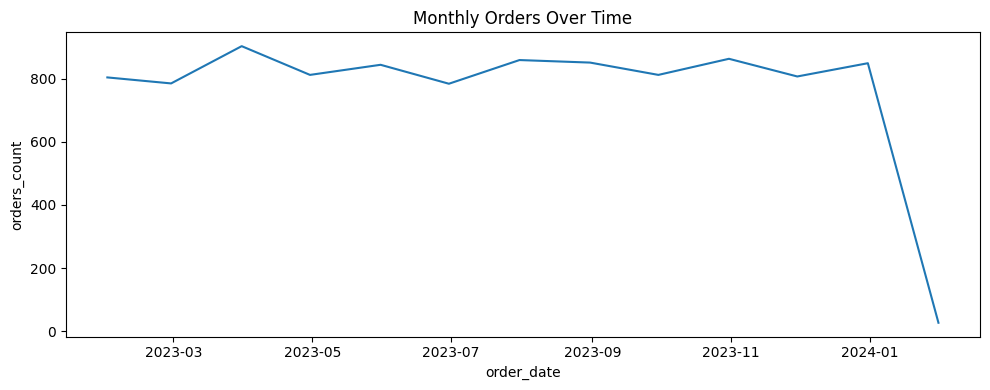

In [57]:
# Plot monthly orders and revenue
plt.figure(figsize=(10,4))
sns.lineplot(x='order_date', y='orders_count', data=monthly)
plt.title('Monthly Orders Over Time')
plt.tight_layout()
plt.show()

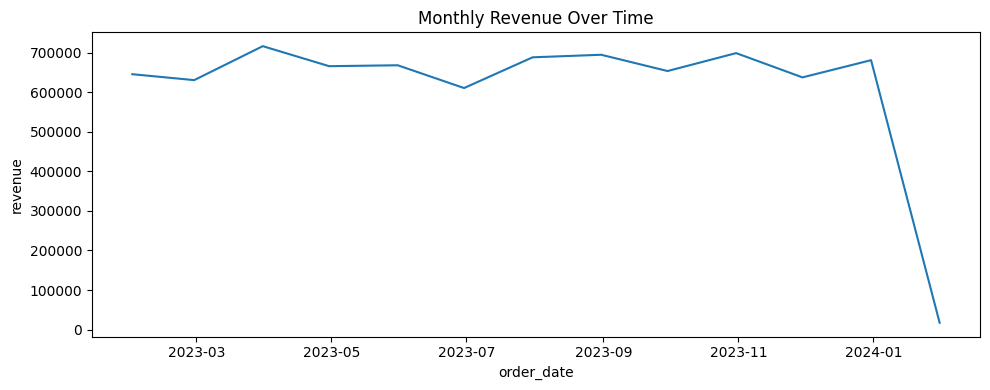

In [58]:
plt.figure(figsize=(10,4))
sns.lineplot(x='order_date', y='revenue', data=monthly)
plt.title('Monthly Revenue Over Time')
plt.tight_layout()

plt.show()

/tmp/ipython-input-288731065.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_stats.head(20), x='total_spent', y='name', palette='viridis')


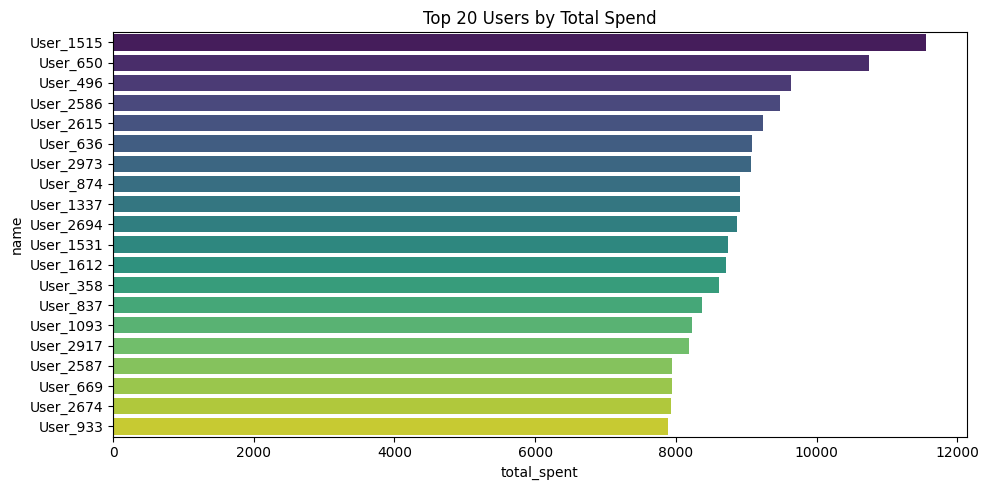

In [61]:
  # 2) User behavior patterns
user_stats = merged.groupby(['user_id', 'name', 'membership', 'city']).agg(
    orders_count=('order_id', 'count'),
    total_spent=('total_amount', 'sum'),
    avg_order_value=('total_amount', 'mean')
).reset_index().sort_values('total_spent', ascending=False)

summaries['user_stats'] = user_stats
# Top 20 users by spending plot
plt.figure(figsize=(10,5))
sns.barplot(data=user_stats.head(20), x='total_spent', y='name', palette='viridis')
plt.title('Top 20 Users by Total Spend')
plt.tight_layout()
plt.show()
